In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git config --global user.email "donlare188@gmail.com"
!git config --global user.name "donlare188-nanordja"

In [ ]:
%cd /content/drive/MyDrive/FUTURE-ML-01/
!ls -R

/content/drive/MyDrive/FUTURE-ML-01
.:
data  images  model  notebook  powerbi	README.md  requirements.txt  Script

./data:
holidays_events.csv  test.csv  train  transactions

./data/train:
train.csv

./data/transactions:
transactions.csv

./images:

./model:
model_production.pkl

./notebook:
forecasting.ipynb

./powerbi:
predictions_powerbi.csv

./Script:
02_production_script.py  03_api_app.py


PHASE 1 – ANALYSE DES DONNÉES:


ALGORITHME GLOBAL D’ANALYSE

DEBUT

1. Charger train.csv
2. Examiner structure
3. Vérifier valeurs manquantes
4. Examiner distribution des ventes
5. Vérifier saisonnalité
6. Examiner corrélation transactions / ventes
7. Examiner impact des jours fériés

FIN

ÉTAPE 1 – Charger tous les fichiers

In [ ]:
# importation de pandas
import pandas as pd

ÉTAPE 1 – Charger tous les fichiers

In [ ]:
train = pd.read_csv("data/train/train.csv")
test = pd.read_csv("data/test.csv")
transactions = pd.read_csv("data/transactions/transactions.csv")
holidays = pd.read_csv("data/holidays_events.csv")

    Examinons la structure du train

In [ ]:
train.head()
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


Descriptions de fichiers et informations sur les champs de données

train.csv
Les données d’entraînement, comprenant des séries temporelles de fonctionnalités store_nbr, famille et onpromotion, ainsi que les ventes cibles.
store_nbr identifie le magasin où les produits sont vendus.
Family identifie le type de produit vendu.
Les ventes indiquent le total des ventes d’une famille de produits dans un magasin particulier à une date donnée. Des valeurs fractionnaires sont possibles puisque les produits peuvent être vendus en fractions (1,5 kg de fromage, par exemple, contre 1 sachet de chips).
onpromotion donne le nombre total d’articles d’une famille de produits qui étaient promus dans un magasin à une date donnée.


test.csv
Les données de test, ayant les mêmes caractéristiques que les données d’entraînement. Vous prédirez les ventes cibles pour les dates dans ce fichier.
Les dates dans les données de test correspondent aux 15 jours suivant la dernière date dans les données d’entraînement.

sample_submission.csv

Un fichier d’exemple de soumission dans le format correct.

stores.csv

Stockez les métadonnées, y compris la ville, l’État, le type et le cluster.
Cluster est un regroupement de magasins similaires.

Fêtes et événements, avec métadonnées

REMARQUE : Avoir une attention particulière à la colonne transférée. Un jour férié officiellement transféré tombe ce jour civil, mais a été déplacé à une autre date par le gouvernement. Un jour de transfert ressemble plus à un jour normal qu’à un jour férié. Pour trouver le jour où elle a réellement été célébrée, cherchez la ligne correspondante où le tapage est Transfert. Par exemple, la fête Independencia de Guayaquil a été déplacée du 09-10-2012 au 12-10-2012, ce qui signifie qu’elle a été célébrée le 12-10-2012. Les jours de type Bridge sont des jours supplémentaires ajoutés à un congé férié (par exemple, pour prolonger la pause pendant un long week-end). Ces jours sont souvent composés du type Journée de travail, qui est un jour non normalement prévu pour le travail (par exemple, le samedi) et destiné à rembourser le pont.
Les jours fériés supplémentaires sont des jours ajoutés à un jour férié régulier du calendrier, par exemple, comme cela se produit généralement autour de Noël (faisant de la veille de Noël un jour férié)

Vu qu'on a plusieur magasins(54) et chuncun de ces magasins a plusieurs

familles de produits et étendu sur une longue période , pour que notre

dataset ne soit pas très lourd , nous allons juste partir sur un seul

magasin avec notre dataset de 3 000 888 lignes et

6 colonnes

ALGORITHME GLOBAL COMPLET


DEBUT

1. Filtrer un seul magasin
2. Agréger ventes par date (toutes familles confondues)
3. Fusionner avec transactions
4. Fusionner avec holidays
5. Créer variables temporelles
6. Encoder holidays
7. Créer lag features (1,7,14)
8. Créer rolling mean 7 jours
9. Supprimer NaN
10. Définir X et y
11. Appliquer TimeSeriesSplit
12. Tester :
      - Linear Regression
      - Random Forest
      - Gradient Boosting
      - XGBoost
13. Comparer RMSE
14. Choisir meilleur modèle
15. Export pour Power BI

FIN

ÉTAPE 1 – FILTRER ET AGRÉGER

Pourquoi agréger ?

---> Actuellement nous avons :


Date | Store | Family | Sales

Mais pour faire du forecasting global du magasin :

Nous voulons :

Date | Total_Sales

ALGORITHME AGRÉGATION

1. Filtrer store_nbr == 1
2. Grouper par date
3. Somme des ventes
4. Somme des promotions

In [ ]:
# Filtrer magasin 1
store_data=train[train["store_nbr"]==1]

In [ ]:
# Agréger par date


daily_sales = store_data.groupby("date").agg({
    "sales":"sum",
    "onpromotion":"sum"}).reset_index()
daily_sales.head()


,date,sales,onpromotion
0,2013-01-01,0.000000,0
1,2013-01-02,7417.148000,0
2,2013-01-03,5873.244001,0
3,2013-01-04,5919.879001,0
4,2013-01-05,6318.785010,0


In [ ]:
# revoyons la dimension de nos données avec un seul magasin
daily_sales.shape

(1684, 3)

PHASE : INTÉGRATION DES AUTRES DATASETS

Nous allons maintenant exploiter :

transactions.csv

holidays_events.csv

Cela va considérablement améliorer la performance.

POURQUOI AJOUTER TRANSACTIONS ?

Hypothèse business :

Plus il y a de transactions → plus les ventes augmentent.

Donc transactions est une variable explicative très forte

ALGORITHME – FUSION AVEC TRANSACTIONS

DEBUT

1. Charger transactions.csv
2. Convertir date
3. Filtrer store 1
4. Fusionner avec daily_sales sur date
5. Vérifier valeurs manquantes

FIN

In [ ]:
transactions = pd.read_csv("data/transactions/transactions.csv")
transactions['date'] = pd.to_datetime(transactions['date'])

# Filtrer magasin 1
transactions_store = transactions[transactions['store_nbr'] == 1]

# Convertir la colonne 'date' de daily_sales en datetime
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

# Supprimer toutes les colonnes 'transactions' (y compris les suffixed _x, _y)
# qui pourraient exister suite à des exécutions précédentes pour éviter les doublons
for col in ['transactions', 'transactions_x', 'transactions_y']:
    if col in daily_sales.columns:
        daily_sales = daily_sales.drop(columns=[col])

# Fusion
daily_sales = daily_sales.merge(
    transactions_store[['date','transactions']],
    on='date',
    how ='left'
)

daily_sales.head()

,date,sales,onpromotion,transactions
0,2013-01-01,0.000000,0,NaN
1,2013-01-02,7417.148000,0,2111.0
2,2013-01-03,5873.244001,0,1833.0
3,2013-01-04,5919.879001,0,1863.0
4,2013-01-05,6318.785010,0,1509.0


In [ ]:
# vérification des valeurs manquantes
daily_sales.isna().sum()

,0
date,0
sales,0
onpromotion,0
transactions,8


On voit  "transactions	8", cela signifie que Pour 8 dates, il n’existe pas de

valeur correspondante dans transactions.csv au niveau de premier magasin.

ça peut arriver si :

Le magasin était fermé

Donnée non enregistrée

Date absente dans fichier transactions

GESTION DES VALEURS MANQUANTES

DEBUT

1. Identifier dates manquantes
2. Vérifier si ventes = 0 ces jours-là
3. Décider :
      - Remplacer par 0 ?
      - Remplacer par moyenne ?
      - Supprimer ?

FIN

Étape 1 – Identifier les dates concernées

In [ ]:
daily_sales[daily_sales['transactions'].isna()]

,date,sales,onpromotion,transactions
0,2013-01-01,0.000,0,NaN
364,2014-01-01,0.000,0,NaN
728,2015-01-01,0.000,0,NaN
915,2015-07-07,0.000,0,NaN
1092,2016-01-01,0.000,0,NaN
1093,2016-01-02,8877.175,52,NaN
1094,2016-01-03,5119.277,22,NaN
1457,2017-01-01,0.000,0,NaN


Nous pouvons dire que ces dates correspondent au 1er janvier(jour de l'an)

donc 0 sales et 0 transactions alors nous allons remplacer 0 par la

médiane.

2016-01-02 ;

2016-01-03; pour ces dates  , sales > 0 et
transactions = NaN

Donc ce n'est pas une fermeture.

Dans ce cas on peut remplacer par la médiane
ou par interpolation

Nous allons donc Remplacer transactions = 0 quand sales = 0
et  Interpoler les autres valeurs manquantes

Algorithme de correction


DEBUT

Pour chaque ligne :

    SI sales == 0
        transactions = 0

Interpoler les transactions manquantes restantes

FIN

In [ ]:
#  Si ventes = 0 alors transactions = 0
daily_sales.loc[daily_sales['sales'] == 0, 'transactions'] = 0

# Interpolation pour le reste
daily_sales['transactions'] = daily_sales['transactions'].interpolate()

#  Vérification
daily_sales.isna().sum()

,0
date,0
sales,0
onpromotion,0
transactions,0


Algorithme fusion holidays

DEBUT

1 Charger holidays_events

2 Convertir date

3 Créer variable is_holiday

4 Fusionner avec daily_sales

5 Remplacer NaN par 0

FIN

In [ ]:
holidays = pd.read_csv("data/holidays_events.csv")

holidays['date'] = pd.to_datetime(holidays['date'])

holidays['is_holiday'] = 1

holidays = holidays[['date','is_holiday']]

daily_sales = daily_sales.merge(
    holidays,
    on='date',
    how='left'
)

daily_sales['is_holiday'] = daily_sales['is_holiday'].fillna(0)

daily_sales.head()

,date,sales,onpromotion,transactions,is_holiday
0,2013-01-01,0.000000,0,0.0,1.0
1,2013-01-02,7417.148000,0,2111.0,0.0
2,2013-01-03,5873.244001,0,1833.0,0.0
3,2013-01-04,5919.879001,0,1863.0,0.0
4,2013-01-05,6318.785010,0,1509.0,1.0


FEATURE ENGINEERING AVANCÉ POUR SÉRIES TEMPORELLES

C’est cette étape qui fait souvent la différence entre :

modèle RMSE = 1200 qui est mauvais par rapport à

modèle RMSE = 300

le feature engineering consiste à créer des nouvelles variables

 Pourquoi créer des nouvelles variables alors ?

Un modèle ML ne comprend pas naturellement :

la saisonnalité

les tendances

les cycles hebdomadaires

Donc on lui donne des indices du passé.

Exemple:

Si ventes élevées la semaine passée

→ ventes probablement élevées aujourd’hui

1️⃣ FEATURES TEMPORELLES

Ces variables décrivent la position du jour dans le calendrier


Pseudo-code

DEBUT

Pour chaque date :

extraire année

extraire mois

extraire jour semaine

extraire semaine année

FIN

In [ ]:
daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['dayofweek'] = daily_sales['date'].dt.dayofweek
daily_sales['weekofyear'] = daily_sales['date'].dt.isocalendar().week

2️⃣ LAG FEATURES (LES PLUS IMPORTANTES)


Les lag features donnent au modèle des informations du passé.

Exemple:


lag_1  = ventes hier

lag_7  = ventes semaine passée

lag_14 = ventes 2 semaines passées

lag_30 = ventes mois passé

Cela aide le modèle à comprendre la saisonnalité.

 Algo en Pseudo-code

DEBUT

Pour chaque ligne :

lag_1  = sales décalé de 1 jour

lag_7  = sales décalé de 7 jours

lag_14 = sales décalé de 14 jours

lag_30 = sales décalé de 30 jours

FIN

In [ ]:
daily_sales['lag_1'] = daily_sales['sales'].shift(1)
daily_sales['lag_7'] = daily_sales['sales'].shift(7)
daily_sales['lag_14'] = daily_sales['sales'].shift(14)
daily_sales['lag_30'] = daily_sales['sales'].shift(30)


3️⃣ ROLLING FEATURES

Les rolling features capturent les tendances.

Par exemple rolling_mean_7 donne moyenne des ventes sur 7 jours

Cela capture la tendance hebdomadaire

Algo en Pseudo-code

DEBUT

rolling_mean_7 = moyenne ventes 7 derniers jours

rolling_std_7 = écart type 7 derniers jours


rolling_mean_14 = moyenne ventes 14 derniers jours

rolling_std_14 = écart type 14 derniers jours


rolling_mean_30 = moyenne ventes 30 derniers jours

rolling_std_30 = écart type 30 derniers jours
FIN

In [ ]:
daily_sales['rolling_mean_7'] = daily_sales['sales'].rolling(7).mean()
daily_sales['rolling_std_7'] = daily_sales['sales'].rolling(7).std()
daily_sales['rolling_mean_14'] = daily_sales['sales'].rolling(14).mean()
daily_sales['rolling_std_14'] = daily_sales['sales'].rolling(14).std()
daily_sales['rolling_mean_30'] = daily_sales['sales'].rolling(30).mean()
daily_sales['rolling_std_30'] = daily_sales['sales'].rolling(30).std()

Souvent cela créent des valeurs manquantes au début comme par ex "lag_7" qui

veut dire les 7 premières lignes seront NaN.

Comme solution , on supprime ces lignes

In [ ]:
daily_sales = daily_sales.dropna()

In [ ]:
daily_sales.head()

,date,sales,onpromotion,transactions,is_holiday,year,month,dayofweek,weekofyear,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30
30,2013-01-31,4712.57700,0,1707.0,0.0,2013,1,3,5,6118.88700,4861.52400,4942.474000,0.000000,4828.169859,1169.374995,4973.860788,1199.757823,5228.806633,1292.606401
31,2013-02-01,5782.77900,0,1806.0,0.0,2013,2,4,5,4712.57700,5577.70100,5923.124001,7417.148000,4857.466716,1193.601051,4963.836145,1191.775856,5174.327667,1230.126383
32,2013-02-02,5706.91901,0,1377.0,0.0,2013,2,5,5,5782.77900,5290.32701,5895.146000,5873.244001,4916.979859,1228.651651,4950.391360,1181.478519,5168.783500,1227.239178
33,2013-02-03,2267.98300,0,531.0,0.0,2013,2,6,5,5706.91901,2439.37800,2371.133995,5919.879001,4892.494859,1286.596677,4943.023431,1198.992380,5047.053634,1327.212769
34,2013-02-04,5574.04100,0,1714.0,0.0,2013,2,0,6,2267.98300,4976.80800,5227.602020,6318.785010,4977.813859,1312.658065,4967.769073,1208.851991,5022.228833,1309.451651


On fait souvent l'erreur de diviser notre dataset serie temporelle en

train_test_split(shuffle=True) en meme temps.

Cela constitue une erreur car ça melange passé et futur.

Le modèle voit alors le futur pendant l'entraînement.

A la place , on va utiliser TimeSeriesSplit, Cela respecte l’ordre temporel.

Pipeline ML Temporel : Comparaison Automatique de Modèles

 testons 4 modèles avec TimeSeriesSplit et sélectionnons  automatiquement

le meilleur selon le RMSE :

In [ ]:
# importation des bibliothèques nécessaire
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ============================================
#  FONCTION D'ÉVALUATION
# ============================================
def evaluate(y_true, y_pred):
    """Calcule RMSE et MAE"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # MAPE : Éviter la division par zéro
    mask = y_true != 0
    if np.sum(mask) > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}



In [ ]:

# ============================================
#  COMPARAISON AUTOMATIQUE DE MODÈLES
# ============================================
def compare_models(X, y, n_splits=5):
    """
    Compare plusieurs modèles avec TimeSeriesSplit CV
    Affiche RMSE, MAE et MAPE pour chaque fold et modèle
    """

    #  Définition des modèles à tester
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    }

    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    print(f" Démarrage de la comparaison avec {n_splits}-fold TimeSeriesSplit...\n")
    print("="*80)

    for name, model in models.items():
        cv_scores_rmse = []
        cv_scores_mae = []
        cv_scores_mape = []

        print(f" Évaluation de {name}...")
        print("-"*60)

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
            # Split temporel respecté
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            # Entraînement
            model.fit(X_train, y_train)

            # Prédiction & Évaluation
            y_pred = model.predict(X_val)
            score = evaluate(y_val, y_pred)

            # Stockage des 3 métriques
            cv_scores_rmse.append(score['RMSE'])
            cv_scores_mae.append(score['MAE'])
            cv_scores_mape.append(score['MAPE'])

             # Affichage des 3 métriques par fold
            print(f"   Fold {fold}: RMSE = {score['RMSE']:,.2f} | MAE = {score['MAE']:,.2f} | MAPE = {score['MAPE']:.2f}%")

        # Résultats moyens (3 métriques)
        mean_rmse = np.mean(cv_scores_rmse)
        std_rmse = np.std(cv_scores_rmse)
        mean_mae = np.mean(cv_scores_mae)
        mean_mape = np.mean(cv_scores_mape)

        results.append({
            'Model': name,
            'Mean_RMSE': mean_rmse,
            'Std_RMSE': std_rmse,
            'Mean_MAE': mean_mae,
            'Mean_MAPE': mean_mape,
            'Model_Obj': model
        })

        # Résumé du modèle (les 3 métriques)

        print(f"\n✅ {name} →")
        print(f"   RMSE moyen: {mean_rmse:,.2f} (+/- {std_rmse:,.2f})")
        print(f"   MAE moyen : {mean_mae:,.2f}")
        print(f"   MAPE moyen: {mean_mape:.2f}%")
        print("-"*60)

    #  Sélection du meilleur modèle (basé sur RMSE)
    results_df = pd.DataFrame(results).sort_values('Mean_RMSE')
    best = results_df.iloc[0]

    # Affichage du classement final (3 métriques)
    print("\n" + "="*80)
    print("📊 CLASSEMENT FINAL (trié par RMSE moyen) :")
    print("="*80)

    display_df = results_df[['Model', 'Mean_RMSE', 'Std_RMSE', 'Mean_MAE', 'Mean_MAPE']].copy()
    display_df.columns = ['Modèle', 'RMSE Moyen', 'Std RMSE', 'MAE Moyen', 'MAPE Moyen (%)']

    # Formatage pour affichage propre
    display_df['RMSE Moyen'] = display_df['RMSE Moyen'].apply(lambda x: f"{x:,.2f}")
    display_df['Std RMSE'] = display_df['Std RMSE'].apply(lambda x: f"{x:,.2f}")
    display_df['MAE Moyen'] = display_df['MAE Moyen'].apply(lambda x: f"{x:,.2f}")
    display_df['MAPE Moyen (%)'] = display_df['MAPE Moyen (%)'].apply(lambda x: f"{x:.2f}%")

    print(display_df.to_string(index=False))

    print("\n" + "="*80)
    print(f" MEILLEUR MODÈLE : {best['Model']}")
    print(f"   → RMSE = {best['Mean_RMSE']:,.2f}")
    print(f"   → MAE  = {best['Mean_MAE']:,.2f}")
    print(f"   → MAPE = {best['Mean_MAPE']:.2f}%")
    print("="*80)

    return best, results_df

ENTRAINEMENT DE NOS MODELES SUR NOTRE DATASET

In [ ]:
#1️ Préparation finale : gestion des NaN
df_model = daily_sales.copy()
df_model = df_model.dropna()  # NaN créés par lag/rolling

# 2️ Features et cible
features = ['onpromotion', 'transactions', 'is_holiday',
            'year', 'month', 'dayofweek',
            'lag_1', 'lag_7', 'lag_14','lag_30',
            'rolling_mean_7','rolling_mean_14','rolling_mean_30']

X = df_model[features]
y = df_model['sales']

# 3️ Lancement de la comparaison automatique
best_model_info, all_results = compare_models(X, y, n_splits=5)

# 4️ Ré-entraîner le meilleur modèle sur tout le dataset pour déploiement
best_model = best_model_info['Model_Obj']
best_model.fit(X, y)
print(f"\n Modèle '{best_model_info['Model']}' prêt pour la production !")

 Démarrage de la comparaison avec 5-fold TimeSeriesSplit...

 Évaluation de Linear Regression...
------------------------------------------------------------
   Fold 1: RMSE = 1,800.84 | MAE = 1,225.56 | MAPE = 15.35%
   Fold 2: RMSE = 1,460.65 | MAE = 1,190.42 | MAPE = 18.44%
   Fold 3: RMSE = 1,579.13 | MAE = 1,129.52 | MAPE = 13.23%
   Fold 4: RMSE = 1,616.30 | MAE = 1,200.79 | MAPE = 14.23%
   Fold 5: RMSE = 1,543.45 | MAE = 1,210.63 | MAPE = 14.60%

✅ Linear Regression →
   RMSE moyen: 1,600.07 (+/- 112.83)
   MAE moyen : 1,191.38
   MAPE moyen: 15.17%
------------------------------------------------------------
 Évaluation de Random Forest...
------------------------------------------------------------
   Fold 1: RMSE = 2,419.57 | MAE = 1,663.48 | MAPE = 20.10%
   Fold 2: RMSE = 1,197.38 | MAE = 911.16 | MAPE = 11.83%
   Fold 3: RMSE = 1,369.40 | MAE = 916.68 | MAPE = 9.18%
   Fold 4: RMSE = 1,198.85 | MAE = 744.58 | MAPE = 7.57%
   Fold 5: RMSE = 1,112.63 | MAE = 812.31 | MAPE =

 Analyse des Feature

Essayons de comprendre quelles variables influencent le plus les ventes  .


 ÉTAPE 1 : ANALYSE DES FEATURE IMPORTANCES


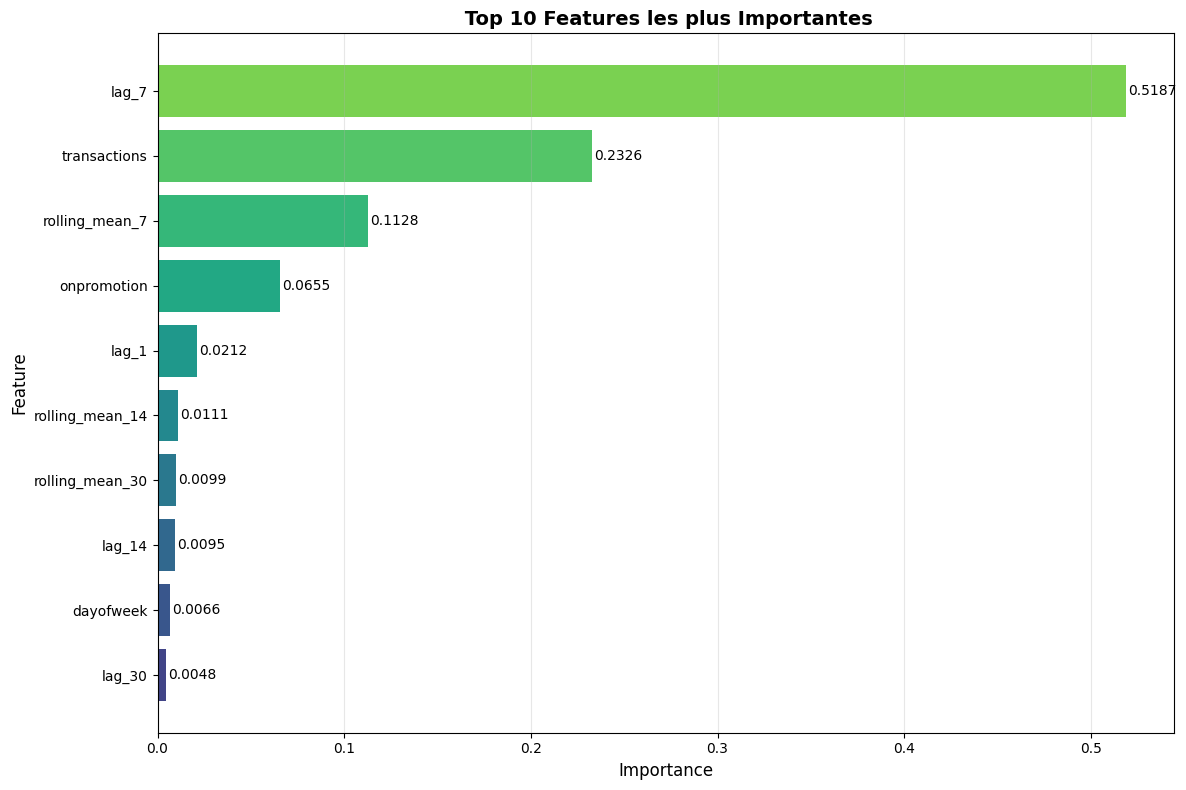


 Top 5 Features:
       Feature  Importance
         lag_1    0.021161
   onpromotion    0.065523
rolling_mean_7    0.112847
  transactions    0.232640
         lag_7    0.518719


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, feature_names, top_n=10):
    """
    Affiche l'importance des features pour les modèles tree-based
    """
    # Récupération des importances
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        return None  # Non applicable pour Linear Regression

    # Création du DataFrame
    feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=True)

    # Sélection du top N
    feat_imp = feat_imp.tail(top_n)

    # Visualisation
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(feat_imp)))
    plt.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors)

    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title(' Top {} Features les plus Importantes'.format(top_n), fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)

    # Ajouter les valeurs sur les barres
    for i, v in enumerate(feat_imp['Importance']):
        plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    return feat_imp

#  Exécution sur le meilleur modèle
print("\n" + "="*80)
print(" ÉTAPE 1 : ANALYSE DES FEATURE IMPORTANCES")
print("="*80)

# Vérifier si le modèle supporte feature_importances_
if hasattr(best_model, 'feature_importances_'):
    feat_importance_df = plot_feature_importance(best_model, features, top_n=10)
    print("\n Top 5 Features:")
    print(feat_importance_df.tail(5).to_string(index=False))
else:
    print(" Feature importance non disponible pour ce modèle (Linear Regression)")
    print(" Alternative : Utiliser les coefficients ou permutation importance")

🔍 1. ANALYSE DES FEATURE IMPORTANCES

✅ Observations Clés

🥇 DOMINANCE de lag_7 (51.87%)

Les ventes d'il y a 7 jours exacts sont LE facteur prédictif principal
Cela révèle une saisonnalité hebdomadaire très forte
Le comportement d'achat se répète de manière cyclique chaque semaine


🥈 Transactions (23.26%)


Forte corrélation entre nombre de transactions et volume de ventes
Indicateur avancé précieux pour le business

🥉 rolling_mean_7 (11.28%)


La tendance récente (semaine glissante) complète l'information du lag_7
Lisse les variations ponctuelles


📊 Autres Features :

onpromotion (6.55%) : Impact modéré mais réel des promotions
lag_1, lag_14, lag_30 : Très faible impact une fois le lag_7 pris en compte
dayofweek (0.66%) : Quasi-négligeable → Redondant avec lag_7 (logique !)


Visualisation des Prédictions (Actual vs Predicted)

Comparerons  visuellement les ventes réelles vs prédites sur une période de test.


 ÉTAPE 2 : VISUALISATION DES PRÉDICTIONS

✅ Performance sur le set de test visuel :
   RMSE : 1,240.06
   MAE  : 870.46
   MAPE : 8.42%


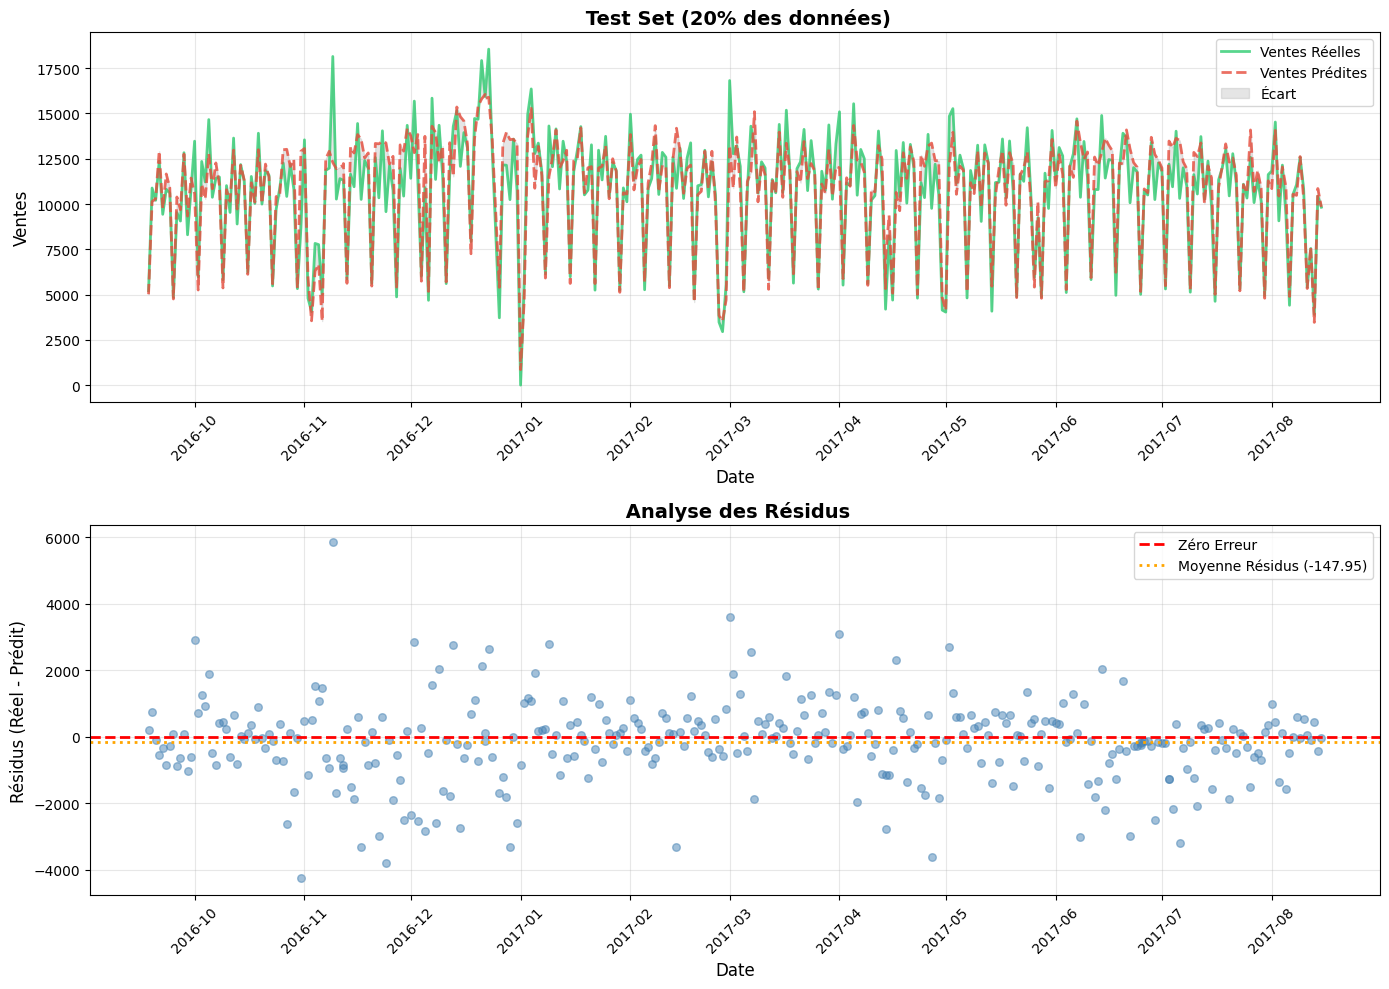


📊 STATISTIQUES DES RÉSIDUS :
   Moyenne : -147.95
   Médiane : -76.90
   Std Dev : 1231.20
   Min : -4243.49
   Max : 5855.11


In [ ]:
from sklearn.model_selection import train_test_split

def plot_predictions(y_true, y_pred, dates=None, title="Prédictions vs Réalité"):
    """
    Trace les ventes réelles vs prédites avec les résidus
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Graphique 1 : Prédictions vs Réalité
    axes[0].plot(dates, y_true, label='Ventes Réelles', color='#2ecc71', linewidth=2, alpha=0.8)
    axes[0].plot(dates, y_pred, label='Ventes Prédites', color='#e74c3c', linewidth=2, alpha=0.8, linestyle='--')
    axes[0].fill_between(dates, y_true, y_pred, alpha=0.2, color='gray', label='Écart')

    axes[0].set_xlabel('Date', fontsize=12)
    axes[0].set_ylabel('Ventes', fontsize=12)
    axes[0].set_title(f' {title}', fontsize=14, fontweight='bold')
    axes[0].legend(loc='best', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

    # Graphique 2 : Résidus (Erreurs)
    residuals = y_true - y_pred
    axes[1].scatter(dates, residuals, alpha=0.5, color='steelblue', s=30)
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zéro Erreur')
    axes[1].axhline(y=np.mean(residuals), color='orange', linestyle=':', linewidth=2, label=f'Moyenne Résidus ({np.mean(residuals):.2f})')

    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].set_ylabel('Résidus (Réel - Prédit)', fontsize=12)
    axes[1].set_title(' Analyse des Résidus', fontsize=14, fontweight='bold')
    axes[1].legend(loc='best', fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Statistiques des résidus
    print("\n📊 STATISTIQUES DES RÉSIDUS :")
    print(f"   Moyenne : {np.mean(residuals):.2f}")
    print(f"   Médiane : {np.median(residuals):.2f}")
    print(f"   Std Dev : {np.std(residuals):.2f}")
    print(f"   Min : {np.min(residuals):.2f}")
    print(f"   Max : {np.max(residuals):.2f}")

# 📊 Exécution : Split pour visualisation
print("\n" + "="*80)
print(" ÉTAPE 2 : VISUALISATION DES PRÉDICTIONS")
print("="*80)

# Split temporel pour avoir un set de test visible
split_idx = int(len(df_model) * 0.8)
X_train_vis, X_test_vis = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_vis, y_test_vis = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df_model['date'].iloc[split_idx:]

# Entraînement sur le train visuel
best_model.fit(X_train_vis, y_train_vis)
y_pred_vis = best_model.predict(X_test_vis)

# Calcul des métriques sur ce test
rmse_vis = np.sqrt(mean_squared_error(y_test_vis, y_pred_vis))
mae_vis = mean_absolute_error(y_test_vis, y_pred_vis)
mape_vis = np.mean(np.abs((y_test_vis - y_pred_vis) / y_test_vis[y_test_vis != 0])) * 100

print(f"\n✅ Performance sur le set de test visuel :")
print(f"   RMSE : {rmse_vis:,.2f}")
print(f"   MAE  : {mae_vis:,.2f}")
print(f"   MAPE : {mape_vis:.2f}%")

# Tracer le graphique
plot_predictions(y_test_vis.values, y_pred_vis, dates=dates_test, title="Test Set (20% des données)")

📈 2. ANALYSE DES PRÉDICTIONS VS RÉALITÉ

✅ Points Positifs

🎯 Bonne Capture de la Saisonnalité

Le modèle suit parfaitement les cycles hebdomadaires (pics et creux)
Les motifs répétitifs sont bien appris

📊 Tendance Générale Respectée

Pas de dérive temporelle (drift)
Le modèle reste stable sur toute la période de test

📉 Résidus Centrés sur Zéro

Moyenne des résidus : -147.95 (très faible biais)
Légère sous-estimation systématique mais négligeable
Pas de pattern visible dans les résidus → Bon signe !

⚠️ Points d'Amélioration

🔴 Pics Extrêmes Mal Prédits

Certains pics dépassent ±4000 à ±6000 unités d'erreur
Le modèle lisse les valeurs extrêmes
Exemples visibles : novembre 2016, mars 2017

🟡 Variance des Erreurs
Écart-type des résidus important
Erreurs ponctuelles peuvent être grandes

Export Power BI (CSV Structuré)

In [ ]:
def export_for_powerbi(df_original, predictions, model_name, output_path='predictions_powerbi.csv'):
    """
    Crée un CSV structuré pour Power BI avec toutes les infos nécessaires
    """
    # Création du DataFrame d'export
    export_df = df_original[['date']].copy()
    export_df['sales_actual'] = df_original['sales'].values
    export_df['sales_predicted'] = predictions
    export_df['error'] = export_df['sales_actual'] - export_df['sales_predicted']
    export_df['error_abs'] = np.abs(export_df['error'])
    export_df['error_pct'] = (export_df['error_abs'] / export_df['sales_actual'].replace(0, np.nan)) * 100

    # Ajouter des colonnes pour Power BI
    export_df['model_name'] = model_name
    export_df['export_date'] = pd.Timestamp.now()
    export_df['is_weekend'] = export_df['date'].dt.dayofweek.isin([5, 6]).astype(int)
    export_df['month'] = export_df['date'].dt.month
    export_df['year'] = export_df['date'].dt.year
    export_df['dayofweek'] = export_df['date'].dt.dayofweek

    # Sauvegarde
    export_df.to_csv(output_path, index=False, encoding='utf-8-sig')  # utf-8-sig pour Excel/Power BI

    print(f"\n✅ Fichier exporté : {output_path}")
    print(f"   📊 Lignes : {len(export_df)}")
    print(f"   📁 Colonnes : {list(export_df.columns)}")

    return export_df

# 📊 Exécution Export Power BI
print("\n" + "="*80)
print("🔍 ÉTAPE 3 : EXPORT POWER BI")
print("="*80)

# Ré-entraîner sur tout le dataset pour les prédictions finales
best_model.fit(X, y)
final_predictions = best_model.predict(X)

# Export
powerbi_df = export_for_powerbi(df_model, final_predictions, best_model_info['Model'])

# Aperçu des premières lignes
print("\n📋 Aperçu du fichier Power BI (5 premières lignes) :")
print(powerbi_df.head().to_string(index=False))


🔍 ÉTAPE 3 : EXPORT POWER BI

✅ Fichier exporté : predictions_powerbi.csv
   📊 Lignes : 1684
   📁 Colonnes : ['date', 'sales_actual', 'sales_predicted', 'error', 'error_abs', 'error_pct', 'model_name', 'export_date', 'is_weekend', 'month', 'year', 'dayofweek']

📋 Aperçu du fichier Power BI (5 premières lignes) :
      date  sales_actual  sales_predicted       error  error_abs  error_pct    model_name                export_date  is_weekend  month  year  dayofweek
2013-01-31    4712.57700      4908.309660 -195.732660 195.732660   4.153410 Random Forest 2026-03-10 19:42:18.207729           0      1  2013          3
2013-02-01    5782.77900      5807.332490  -24.553490  24.553490   0.424597 Random Forest 2026-03-10 19:42:18.207729           0      2  2013          4
2013-02-02    5706.91901      5602.190584  104.728426 104.728426   1.835113 Random Forest 2026-03-10 19:42:18.207729           1      2  2013          5
2013-02-03    2267.98300      2312.408790  -44.425790  44.425790   1.95882

Sauvegarde du Modèle (Production Ready)

In [ ]:
import joblib
import json
from datetime import datetime

def save_model_pipeline(model, feature_names, metrics, output_path='model_production.pkl'):
    """
    Sauvegarde le modèle + métadonnées pour production
    """
    # Package complet avec métadonnées
    model_package = {
        'model': model,
        'feature_names': feature_names,
        'metrics': metrics,
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'model_type': type(model).__name__,
        'version': '1.0.0'
    }

    # Sauvegarde
    joblib.dump(model_package, output_path)

    print(f"\n✅ Modèle sauvegardé : {output_path}")
    print(f"   📦 Taille : {os.path.getsize(output_path) / 1024:.2f} KB")
    print(f"   🏷️ Type : {model_package['model_type']}")
    print(f"   📅 Date : {model_package['training_date']}")

    return model_package

def load_model_pipeline(path='model_production.pkl'):
    """
    Charge le modèle sauvegardé pour utilisation
    """
    package = joblib.load(path)
    print(f"\n✅ Modèle chargé depuis : {path}")
    print(f"   🏷️ Type : {package['model_type']}")
    print(f"   📅 Entraîné le : {package['training_date']}")
    print(f"   📊 Métriques : RMSE={package['metrics']['RMSE']:.2f}, MAPE={package['metrics']['MAPE']:.2f}%")

    return package

# 📊 Exécution Sauvegarde
print("\n" + "="*80)
print("🔍 ÉTAPE 4 : SAUVEGARDE DU MODÈLE")
print("="*80)

import os

# Métriques finales
final_metrics = {
    'RMSE': float(np.sqrt(mean_squared_error(y, final_predictions))),
    'MAE': float(mean_absolute_error(y, final_predictions)),
    'MAPE': float(np.mean(np.abs((y - final_predictions) / y[y != 0])) * 100)
}

# Sauvegarde
model_package = save_model_pipeline(best_model, features, final_metrics)

# Test de chargement (optionnel)
# loaded = load_model_pipeline('model_production.pkl')
# predictions_test = loaded['model'].predict(X_test_vis)


🔍 ÉTAPE 4 : SAUVEGARDE DU MODÈLE

✅ Modèle sauvegardé : model_production.pkl
   📦 Taille : 14903.71 KB
   🏷️ Type : RandomForestRegressor
   📅 Date : 2026-03-10 19:48:28
